In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from pathlib import Path
from lifelines import KaplanMeierFitter
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm
import numpy as np
from scipy.stats import gaussian_kde

# Note: This script retains the original thesis development paths and is not intended
# to be executed in the public repository without access to the private data environment.

MAIN_DIR = Path("/Users/chanyoungwoo/Thesis/ATE_CATE")
CATE_H1_FP = MAIN_DIR / "Model_New_horizon_1/csf_cate_train.csv"
CATE_H2_FP = MAIN_DIR / "Model_New_horizon_2/csf_cate_train.csv"
CATE_H3_FP = MAIN_DIR / "Model_New_horizon_3/csf_cate_train.csv"
ATE_H1_TEST_FP = MAIN_DIR / "Model_New_horizon_1/csf_ate_test.csv"
ATE_H2_TEST_FP = MAIN_DIR / "Model_New_horizon_2/csf_ate_test.csv"
ATE_H3_TEST_FP = MAIN_DIR / "Model_New_horizon_3/csf_ate_test.csv"
CATE_H1_TEST_FP = MAIN_DIR / "Model_New_horizon_1/csf_cate_test.csv"
CATE_H2_TEST_FP = MAIN_DIR / "Model_New_horizon_2/csf_cate_test.csv"
CATE_H3_TEST_FP = MAIN_DIR / "Model_New_horizon_3/csf_cate_test.csv"
VI_H1_FP   = MAIN_DIR / "Model_New_horizon_1/csf_variable_importance.csv"
VI_H2_FP   = MAIN_DIR / "Model_New_horizon_2/csf_variable_importance.csv"
VI_H3_FP   = MAIN_DIR / "Model_New_horizon_3/csf_variable_importance.csv"
PARQUET_FP   = MAIN_DIR / "CSF_data_NEW2/cand_kipa_csf_data_train.parquet"
PARQUET_TEST_FP   = MAIN_DIR / "CSF_data_NEW2/cand_kipa_test_ver10.parquet"

h1 = pd.read_csv(CATE_H1_FP).rename(columns={"tau":"tau1"})
h2 = pd.read_csv(CATE_H2_FP).rename(columns={"tau":"tau2"})
h3 = pd.read_csv(CATE_H3_FP).rename(columns={"tau":"tau3"})
df = h1.merge(h2, on="PX_ID").merge(h3, on="PX_ID")

h1_test = pd.read_csv(CATE_H1_TEST_FP).rename(columns={"tau":"tau1"})
h2_test = pd.read_csv(CATE_H2_TEST_FP).rename(columns={"tau":"tau2"})
h3_test = pd.read_csv(CATE_H3_TEST_FP).rename(columns={"tau":"tau3"})
df_test = h1_test.merge(h2_test, on="PX_ID").merge(h3_test, on="PX_ID")

vi_h1 = pd.read_csv(VI_H1_FP)
vi_h2 = pd.read_csv(VI_H2_FP)
vi_h3 = pd.read_csv(VI_H3_FP)

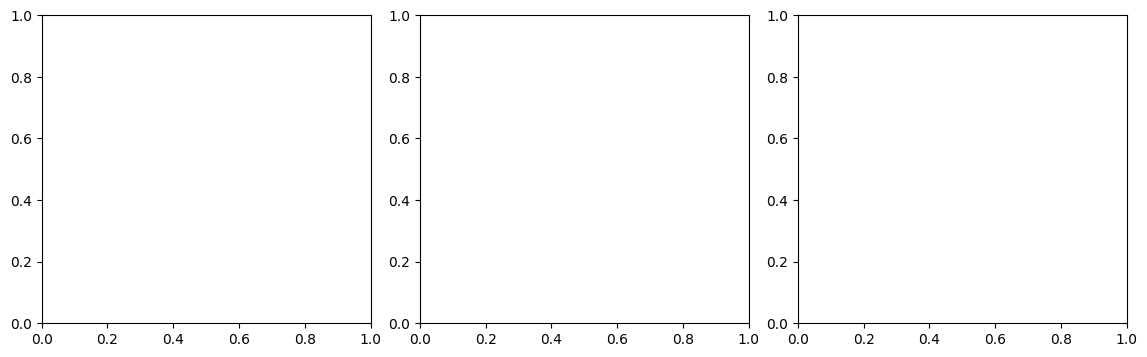

In [47]:
def load_ate(fp: Path):
    ate_df = pd.read_csv(fp)
    est = float(ate_df.loc[0, "estimate"])
    lower = float(ate_df.loc[0, "lower"])
    upper = float(ate_df.loc[0, "upper"])
    return est, lower, upper

taus = [
    ("τ̂ at 1 year", "tau1", (0.25, 0.55, 0.45), ATE_H1_TEST_FP),
    ("τ̂ at 2 years", "tau2", (0.95, 0.55, 0.20), ATE_H2_TEST_FP),
    ("τ̂ at 3 years", "tau3", (0.45, 0.50, 0.85), ATE_H3_TEST_FP),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
plt.subplots_adjust(wspace=0.15)

panel_peaks = []

In [48]:
for ax, (title, col, color, ate_fp) in zip(axes, taus):
    x = df_test[col].dropna().values
    n = x.size
    med = np.median(x)
    q1, q3 = np.percentile(x, [25, 75])
    iqr = (q1, q3)

    ate_est, ate_lo, ate_hi = load_ate(ate_fp)

    n_bins = 80
    counts, bins, _ = ax.hist(
        x, bins=n_bins, density=True, alpha=0.35, color=color, edgecolor="black",  linewidth=0.5
    )
    peak_hist = counts.max() if len(counts) else 0.0

    try:
        kde = gaussian_kde(x)
        xs = np.linspace(np.percentile(x, 0.5), np.percentile(x, 99.5), 400)
        kde_vals = kde(xs)
        ax.plot(xs, kde_vals, color=color, linewidth=2)
        peak_kde = kde_vals.max()
    except Exception:
        peak_kde = 0.0

    panel_peaks.append(max(peak_hist, peak_kde))

    ax.axvline(med, color="black", linestyle=":", linewidth=1.4)

    ax.axvspan(q1, q3, color=color, alpha=0.12)

    text = (
        f"n={n:,}\n"
        f"median={med:.1f}\n"
        f"IQR=[{iqr[0]:.1f}, {iqr[1]:.1f}]\n"
        f"ATE={ate_est:.2f}\n"
        f"95% CI=[{ate_lo:.2f}, {ate_hi:.2f}]"
    )
    ax.text(
        0.03, 0.97, text, transform=ax.transAxes,
        ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, linewidth=0.8)
    )

    ax.set_title(f"Density of {title}", fontsize=13, pad=8)
    ax.set_xlabel("Predicted τ̂ (RMST days)")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Density")

global_ymax = max(panel_peaks) * 1.15 if panel_peaks else None
if global_ymax and np.isfinite(global_ymax) and global_ymax > 0:
    for ax in axes:
        ax.set_ylim(0, global_ymax)

fig.tight_layout()

outdir = MAIN_DIR / "figures"
outdir.mkdir(parents=True, exist_ok=True)
fig.savefig(outdir / "fig_cate_histograms.png", dpi=300, bbox_inches="tight")
fig.savefig(outdir / "fig_cate_histograms.pdf", bbox_inches="tight")
plt.show()